In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path

In [2]:
DATA_DIR = Path("../sample_output/ensemble")

RESULT_FILE = DATA_DIR / "Results.txt"

JITTER = 0.10

MS = 6

FS = 14

In [3]:
###########################################################
# Load ensemble summary
###########################################################

results = np.loadtxt(
    RESULT_FILE,
    skiprows=1
)

R_E = results[:,3]

R_I = results[:,5]

R_total = R_E + R_I

next_cycle = results[:,1].astype(int)

In [5]:
###########################################################
# Load ensemble statistics as a function of tau
###########################################################

data = np.loadtxt(
    DATA_DIR / "ResultsTau.txt"
)

taus = data[:, 0]

NEs = data[:, 1]

NEs_fresh = data[:, 2]

NIs = data[:, 3]

NIs_fresh = data[:, 4]

In [6]:
###########################################################
# Figure 5(a,b)
###########################################################

fig = plt.figure(
    figsize=(10, 8),
    facecolor="white"
)

gs = GridSpec(
    6,
    7
)

<Figure size 1000x800 with 0 Axes>

Text(0.02, 0.72, '$N_{\\mathrm{realizations}}=2000$')

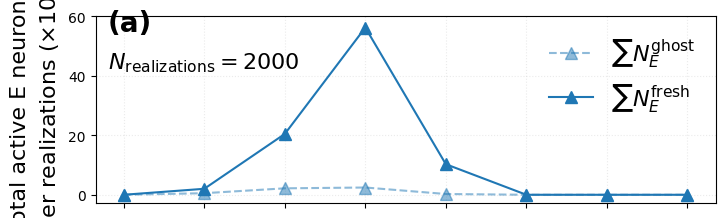

In [7]:
###########################################################
# Figure 5(a,b)
###########################################################

fig = plt.figure(
    figsize=(8, 5),
    facecolor="white"
)

gs = GridSpec(
    6,
    7
)

ax = fig.add_subplot(gs[:3, :])

ghost_E = NEs - NEs_fresh

ax.plot(
    taus,
    ghost_E,
    "--^",
    color="C0",
    alpha=0.5,
    ms=MS+3,
    label=r"$\sum N_E^{\mathrm{ghost}}$"
)

ax.plot(
    taus,
    NEs_fresh,
    "-^",
    color="C0",
    ms=MS+3,
    label=r"$\sum N_E^{\mathrm{fresh}}$"
)

ax.grid(
    linestyle=":",
    alpha=0.25
)

ax.legend(
    frameon=False,
    fontsize=FS+2
)

ax.set_ylabel(
    "Total active E neurons\n"
    r"over realizations ($\times10^3$)",
    fontsize=FS+2
)

ax.set_xticks(range(8))
ax.set_xticklabels([])

ax.set_yticks(
    [0,20000,40000,60000]
)

ax.set_yticklabels(
    [0,20,40,60]
)

ax.text(
    0.02,
    0.92,
    "(a)",
    transform=ax.transAxes,
    fontsize=FS+6,
    fontweight="bold"
)

ax.text(
    0.02,
    0.72,
    r"$N_{\mathrm{realizations}}=2000$",
    transform=ax.transAxes,
    fontsize=FS+2
)

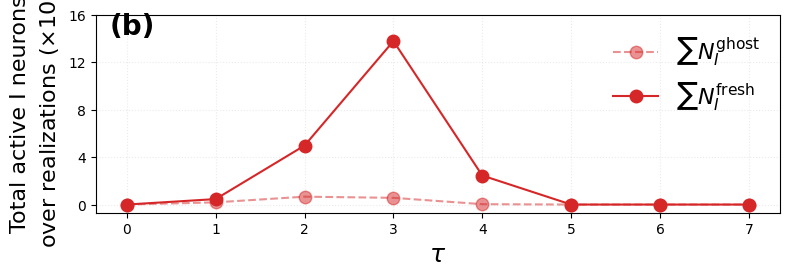

In [8]:
###########################################################
# Figure 5(a,b)
###########################################################

fig = plt.figure(
    figsize=(8, 5),
    facecolor="white"
)

gs = GridSpec(
    6,
    7
)

ax = fig.add_subplot(gs[3:, :])

ghost_I = NIs - NIs_fresh

ax.plot(
    taus,
    ghost_I,
    "--o",
    color="C3",
    alpha=0.5,
    ms=MS+3,
    label=r"$\sum N_I^{\mathrm{ghost}}$"
)

ax.plot(
    taus,
    NIs_fresh,
    "-o",
    color="C3",
    ms=MS+3,
    label=r"$\sum N_I^{\mathrm{fresh}}$"
)

ax.grid(
    linestyle=":",
    alpha=0.25
)

ax.legend(
    frameon=False,
    fontsize=FS+2
)

ax.set_xlabel(
    r"$\tau$",
    fontsize=FS+4
)

ax.set_ylabel(
    "Total active I neurons\n"
    r"over realizations ($\times10^3$)",
    fontsize=FS+2
)

ax.set_yticks(
    [0,4000,8000,12000,16000]
)

ax.set_yticklabels(
    [0,4,8,12,16]
)

ax.text(
    0.02,
    0.90,
    "(b)",
    transform=ax.transAxes,
    fontsize=FS+6,
    fontweight="bold"
)


plt.tight_layout()

plt.savefig(
    "Figure5_ab.pdf",
    bbox_inches="tight"
)

plt.show()

In [9]:
###########################################################
# Predictive variable
###########################################################

RE_fresh = results[:,3]

next_cycle = results[:,1]

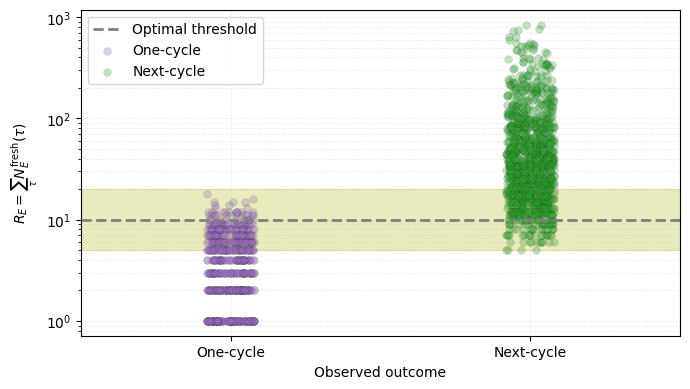

In [10]:
fig = plt.figure(
    figsize=(7,4),
    facecolor="white"
)

ax = fig.add_subplot(111)

jitter = 0.08

ax.axhspan(
    5,
    20,
    color="C8",
    alpha=0.30
)

ax.axhline(
    10,
    color="gray",
    linestyle="--",
    linewidth=2,
    label="Optimal threshold"
)

mask_one = next_cycle == 0

mask_multi = next_cycle == 1

ax.scatter(
    np.random.uniform(
        -jitter,
        jitter,
        np.sum(mask_one)
    ),
    RE_fresh[mask_one],
    s=30,
    color="C4",
    alpha=0.30,
    edgecolors="black",
    linewidths=0.2,
    label="One-cycle"
)

ax.scatter(
    1 + np.random.uniform(
        -jitter,
        jitter,
        np.sum(mask_multi)
    ),
    RE_fresh[mask_multi],
    s=30,
    color="C2",
    alpha=0.30,
    edgecolors="black",
    linewidths=0.2,
    label="Next-cycle"
)

ax.set_xticks([0,1])

ax.set_xticklabels(
    [
        "One-cycle",
        "Next-cycle"
    ]
)

ax.set_yscale("log")

ax.set_xlim(-0.5,1.5)

ax.grid(
    linestyle=":",
    alpha=0.3,
    which="both"
)

ax.set_xlabel(
    "Observed outcome"
)

ax.set_ylabel(
    r"$R_E=\sum_\tau N_E^{\mathrm{fresh}}(\tau)$"
)

ax.legend()

plt.tight_layout()

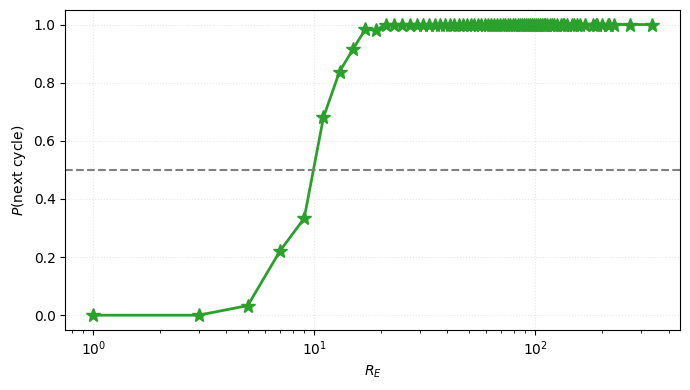

In [11]:
fig = plt.figure(
    figsize=(7,4)
)

ax = fig.add_subplot(111)

bin_width = 2

bins = np.arange(
    0,
    RE_fresh.max()+bin_width,
    bin_width
)

centers = []

probability = []

for left,right in zip(
    bins[:-1],
    bins[1:]
):

    mask = (
        (RE_fresh >= left)
        &
        (RE_fresh < right)
    )

    if np.sum(mask) < 3:
        continue

    centers.append(
        0.5*(left+right)
    )

    probability.append(
        np.mean(
            next_cycle[mask]
        )
    )

ax.plot(
    centers,
    probability,
    "-*",
    color="C2",
    linewidth=2,
    markersize=10
)

ax.axhline(
    0.5,
    color="gray",
    linestyle="--"
)

ax.set_xscale("log")

ax.grid(
    linestyle=":",
    alpha=0.3
)

ax.set_xlabel(r"$R_E$")

ax.set_ylabel(
    r"$P(\mathrm{next\ cycle})$"
)

plt.tight_layout()